In [30]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set()

# CSVを読み込む
df = pd.read_csv('../data/0_KL/1_ShadowHand_SAPG_s4_KL.csv')
#df = pd.read_csv('../data/0_KL/1_ShadowHand_CPOwoAdR_s4_KL.csv')
#df = pd.read_csv('../data/0_KL/1_ShadowHand_CPOwAdR_s4_KL.csv')

#df = pd.read_csv('../data/0_KL/2_AllegroHand_SAPG_s4_KL.csv')
#df = pd.read_csv('../data/0_KL/1_AllegroHand_CPOwoAdR_s4_KL.csv')


print(len(df)) # 全部で52000になる

104000


 98%|█████████▊| 255/260 [03:10<00:03,  1.34it/s]


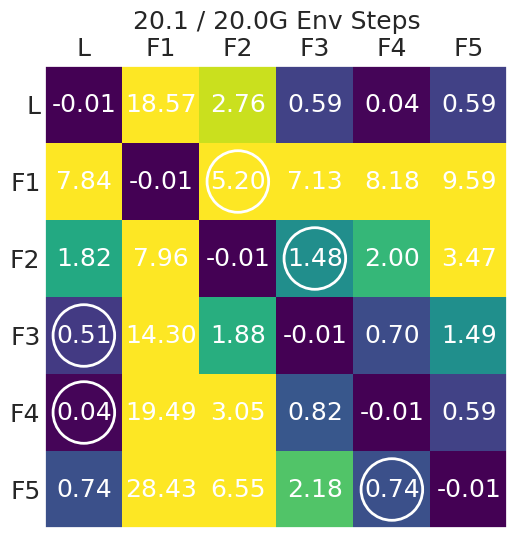

In [31]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import imageio
import os
from tqdm import tqdm


labels = ["L", "F1", "F2", "F3", "F4", "F5"]
save_dir = "frames"
os.makedirs(save_dir, exist_ok=True)
interval = 400
max_envsteps = 20 * 10**9

def epoch_to_envstep(epoch):
    horizon_length = 8
    num_envs = 24576
    envsteps = epoch * num_envs * horizon_length
    return envsteps

# 各ステップの画像を保存
for epoch in tqdm(range(0,len(df),interval)):
    row = df.iloc[epoch]
    tensor = torch.tensor(row.values, dtype=torch.float32).view(6, 6)
    tensor = torch.flip(tensor.flatten(), dims=[0]).view(6, 6)
    data = tensor.numpy()

    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(data, cmap='viridis', vmin=0, vmax=3)

    ax.set_xticks(np.arange(6))
    ax.set_yticks(np.arange(6))
    ax.set_xticklabels(labels, fontsize=18)
    ax.set_yticklabels(labels, fontsize=18)
    ax.xaxis.set_ticks_position('top')
    ax.xaxis.set_label_position('top')
    ax.grid(False)
    ax.tick_params(which='major', length=0)

    # 各セルの値を描画 + 最小値に丸
    for i in range(6):
        row_min_val = float('inf')
        row_min_pos = None
        for j in range(6):
            val = data[i, j]
            ax.text(j, i, f"{val:.2f}", ha='center', va='center', color='white', fontsize=18)

            if i != 0 and i != j and val < row_min_val:
                row_min_val = val
                row_min_pos = (i, j)

        if row_min_pos:
            circle = plt.Circle((row_min_pos[1], row_min_pos[0]), 0.4, color='white', fill=False, linewidth=2)
            ax.add_patch(circle)

    # タイトルに epoch 表示
    envsteps = epoch_to_envstep(epoch)
    ax.set_title(f"{(envsteps/10**9):.1f} / {(max_envsteps/10**9):.1f}G Env Steps", fontsize=18)
    if envsteps >= max_envsteps:
        break

    # 画像保存
    fname = os.path.join(save_dir, f"frame_{epoch:05d}.png")
    plt.tight_layout()
    plt.savefig(fname, bbox_inches='tight', pad_inches=0.1)
    plt.close()






In [32]:
import numpy as np
from PIL import Image
import imageio
import os

images = []
image_files = sorted(os.listdir(save_dir))
image_files = [f for f in image_files if f.endswith('.png')]
for image_file in tqdm(image_files):
    image_path = os.path.join(save_dir, image_file)
    image = imageio.imread(image_path)
    
    # RGBA → RGB に変換
    if image.shape[2] == 4:
        image = image[:, :, :3]

    # 幅が奇数なら、右に1列追加して偶数幅に
    h, w, _ = image.shape
    if w % 2 != 0:
        image = np.pad(image, ((0, 0), (0, 1), (0, 0)), mode='edge')  # 右に1列複製で追加
    
    images.append(image)

# 保存（libx264を使用する場合はwidthが偶数であることが前提）
imageio.mimsave("kl_evolution.mp4", images, fps=30, codec='libx264')
print("✅ 動画保存完了: kl_evolution.mp4")

# save dirを削除
import shutil
shutil.rmtree(save_dir)
print("✅ フレーム保存ディレクトリを削除しました")


  0%|          | 0/255 [00:00<?, ?it/s]/home/mil/shitanda/.pyenv/versions/anaconda3-2023.03/envs/sapg2/lib/python3.7/site-packages/ipykernel_launcher.py:11: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  # This is added back by InteractiveShellApp.init_path()
  2%|▏         | 4/255 [00:00<00:06, 38.95it/s]

100%|██████████| 255/255 [00:06<00:00, 39.97it/s]


✅ 動画保存完了: kl_evolution.mp4


OSError: [Errno 39] Directory not empty: 'frames'